Loading datasets...
Personality data shape: (38, 7)
Personality data columns: ['Id_name', 'Extraversion', 'Agreeableness', 'Conscientiousness', 'Neuroticism', 'Openness', 'SE']
Smiles data shape: (38, 3)
Smiles data columns: ['names', 'smiles', 'total_frames']
Head movements data contains 38 participants

Preparing smiles data...
Merged smiles dataset shape: (38, 12)
Participants with both personality and smiles data: ['wzewmMk_Nzv', 'MKdgEMd_con', 'pjlESEZ_rgA', 'HmakBQy_Zuo', 'PMoGeaZ_lek', 'wpdCAFW_TiI', 'krZcwjd_TUg', 'WfTccuO_NXE', 'opJgPXE_gNj', 'jsjWCIa_tli', 'ELtDENo_vAU', 'geJMdRS_bLD', 'byeCjvS_oUH', 'CJySiDx_fZS', 'CFWyWfu_SpR', 'ybgBimL_qVE', 'MWSDdZj_QXu', 'dnPXJXQ_eFB', 'MlmOdyM_vQZ', 'oNukcaJ_oiz', 'KiWvqaM_UZS', 'zzXHxHz_WTr', 'bdVZIIm_EuX', 'kaDCEmY_jDi', 'VVMgEJO_XFg', 'VzuYqSz_MHc', 'thLwHbd_SOt', 'wDFVbbC_eNY', 'gwdnjsF_tFL', 'RnWlbai_Gab', 'HaKCwkz_Krw', 'exSnMmq_NJW', 'EPhoawa_cLI', 'KTbiJPN_nFG', 'gvjXeOW_XOE', 'QYJOylc_eWg', 'INHfwiw_yNA', 'QZqsLZn_yPM']

SMILES

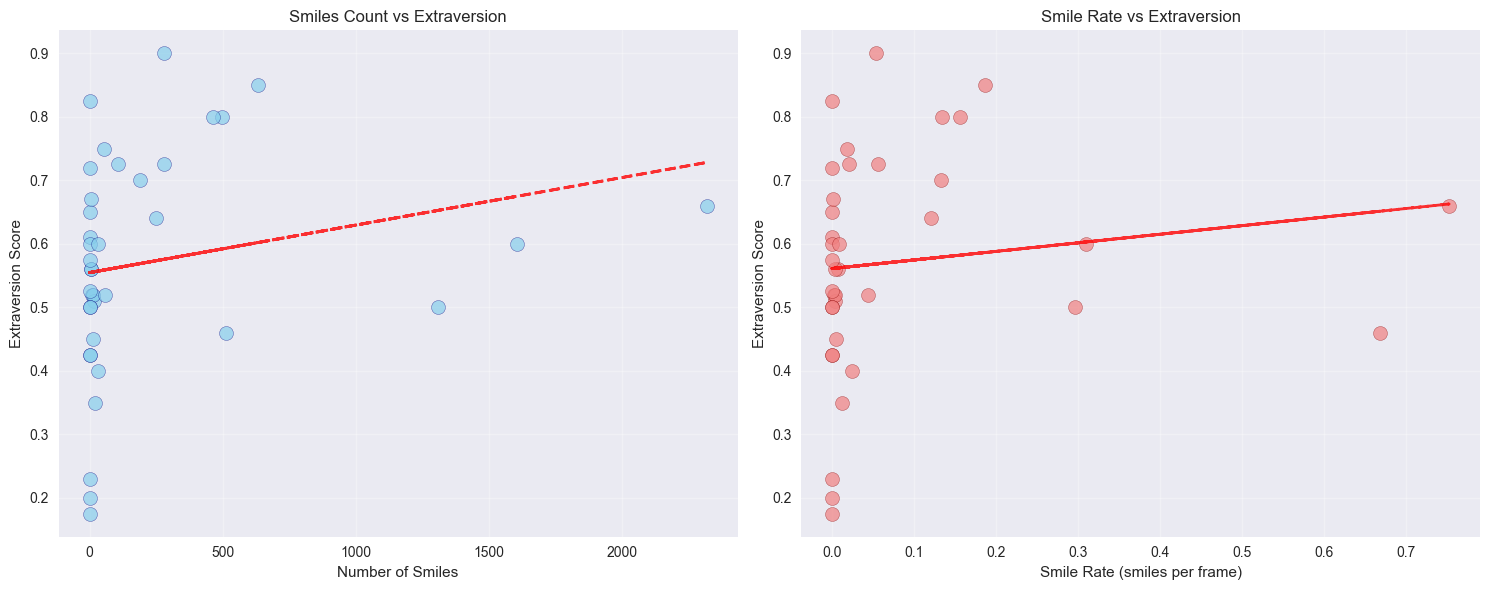


Data Summary:
Number of participants: 38
Average smiles per person: 229.05
Average smile rate: 0.079648
Average Extraversion score: 0.57

Preparing head movements data...
Merged head movements dataset shape: (38, 20)
Participants with both personality and head movement data: ['wzewmMk_Nzv', 'MKdgEMd_con', 'pjlESEZ_rgA', 'HmakBQy_Zuo', 'PMoGeaZ_lek', 'wpdCAFW_TiI', 'krZcwjd_TUg', 'WfTccuO_NXE', 'opJgPXE_gNj', 'jsjWCIa_tli', 'ELtDENo_vAU', 'geJMdRS_bLD', 'byeCjvS_oUH', 'CJySiDx_fZS', 'CFWyWfu_SpR', 'ybgBimL_qVE', 'MWSDdZj_QXu', 'dnPXJXQ_eFB', 'MlmOdyM_vQZ', 'oNukcaJ_oiz', 'KiWvqaM_UZS', 'zzXHxHz_WTr', 'bdVZIIm_EuX', 'kaDCEmY_jDi', 'VVMgEJO_XFg', 'VzuYqSz_MHc', 'thLwHbd_SOt', 'wDFVbbC_eNY', 'gwdnjsF_tFL', 'RnWlbai_Gab', 'HaKCwkz_Krw', 'exSnMmq_NJW', 'EPhoawa_cLI', 'KTbiJPN_nFG', 'gvjXeOW_XOE', 'QYJOylc_eWg', 'INHfwiw_yNA', 'QZqsLZn_yPM']

HEAD MOVEMENTS vs PERSONALITY TRAITS CORRELATION ANALYSIS

Analyzing 12 movement features vs 5 personality traits...
Movement features: ['Roll_mean', '

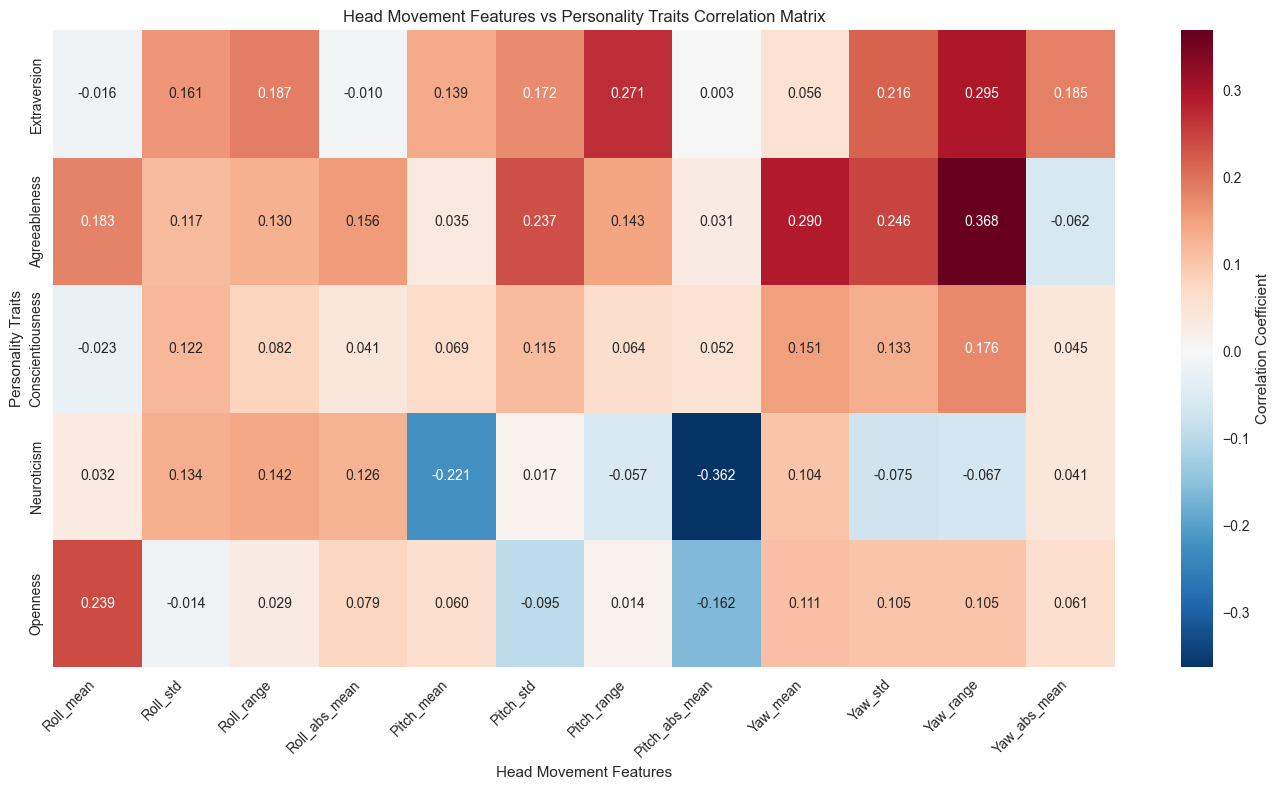


Significant correlations (|r| > 0.3, p < 0.05):
  Agreeableness ↔ Yaw_range: r = 0.3684, p = 0.0229
  Neuroticism ↔ Pitch_abs_mean: r = -0.3625, p = 0.0253

Strongest correlations for each personality trait:
  Extraversion: Yaw_range (r = 0.2954)
  Agreeableness: Yaw_range (r = 0.3684)
  Conscientiousness: Yaw_range (r = 0.1763)
  Neuroticism: Pitch_abs_mean (r = -0.3625)
  Openness: Roll_mean (r = 0.2389)

Data Summary:
Number of participants: 38
Average Roll_mean: 0.9368
Average Roll_std: 3.1485
Average Roll_range: 22.9311
Average Roll_abs_mean: 3.5139
Average Pitch_mean: -0.3134
Average Pitch_std: 3.8504

ANALYSIS COMPLETE


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from scipy.stats import pearsonr
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


def load_datasets():
    """Load and prepare all three datasets"""
    print("Loading datasets...")

    personality_df = pd.read_csv('VPTD_Dataset.csv')
    print(f"Personality data shape: {personality_df.shape}")
    print("Personality data columns:", personality_df.columns.tolist())

    smiles_df = pd.read_csv('smiles.csv')
    print(f"Smiles data shape: {smiles_df.shape}")
    print("Smiles data columns:", smiles_df.columns.tolist())

    with open('head_movements.json', 'r') as f:
        head_movements_raw = json.load(f)
    print(f"Head movements data contains {len(head_movements_raw)} participants")

    return personality_df, smiles_df, head_movements_raw


def extract_id_from_filename(filename):
    """Extract ID from filename by removing .mp4 extension"""
    if filename.endswith('.mp4'):
        return filename[:-4]
    return filename


def prepare_smiles_data(personality_df, smiles_df):
    print("\nPreparing smiles data...")

    smiles_df['id'] = smiles_df['names'].apply(extract_id_from_filename)
    smiles_df['smile_rate'] = smiles_df['smiles'] / smiles_df['total_frames']
    merged_smiles = pd.merge(personality_df, smiles_df, left_on='Id_name', right_on='id', how='inner')

    print(f"Merged smiles dataset shape: {merged_smiles.shape}")
    print("Participants with both personality and smiles data:", merged_smiles['Id_name'].tolist())

    return merged_smiles


def prepare_head_movements_data(personality_df, head_movements_raw):
    """Prepare head movements data for correlation analysis"""
    print("\nPreparing head movements data...")

    head_movements_processed = []

    for participant_id, movements in head_movements_raw.items():
        stats = {'id': participant_id}

        for movement_type in ['Roll', 'Pitch', 'Yaw']:
            if movement_type in movements:
                values = movements[movement_type]
                stats[f'{movement_type}_mean'] = np.mean(values)
                stats[f'{movement_type}_std'] = np.std(values)
                stats[f'{movement_type}_range'] = np.max(values) - np.min(values)
                stats[f'{movement_type}_abs_mean'] = np.mean(np.abs(values))

        head_movements_processed.append(stats)

    head_movements_df = pd.DataFrame(head_movements_processed)
    merged_head_movements = pd.merge(personality_df, head_movements_df, left_on='Id_name', right_on='id', how='inner')

    print(f"Merged head movements dataset shape: {merged_head_movements.shape}")
    print("Participants with both personality and head movement data:", merged_head_movements['Id_name'].tolist())

    return merged_head_movements


def analyze_smiles_extraversion_correlation(merged_smiles):
    """Analyze correlation between smiles and Extraversion"""
    print("\n" + "=" * 60)
    print("SMILES vs EXTRAVERSION CORRELATION ANALYSIS")
    print("=" * 60)

    if len(merged_smiles) < 2:
        print("Not enough data points for correlation analysis.")
        return

    smile_metrics = ['smiles', 'smile_rate']

    for metric in smile_metrics:
        if metric in merged_smiles.columns:
            corr_coef, p_value = pearsonr(merged_smiles[metric], merged_smiles['Extraversion'])
            print(f"\nCorrelation between {metric} and Extraversion:")
            print(f"Correlation coefficient: {corr_coef:.4f}")
            print(f"P-value: {p_value:.4f}")
            print(f"Statistical significance: {'Yes' if p_value < 0.05 else 'No'}")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    axes[0].scatter(merged_smiles['smiles'], merged_smiles['Extraversion'], alpha=0.7, s=100, color='skyblue',
                    edgecolor='navy')
    axes[0].set_xlabel('Number of Smiles')
    axes[0].set_ylabel('Extraversion Score')
    axes[0].set_title('Smiles Count vs Extraversion')
    axes[0].grid(True, alpha=0.3)

    if len(merged_smiles) > 1:
        z = np.polyfit(merged_smiles['smiles'], merged_smiles['Extraversion'], 1)
        p = np.poly1d(z)
        axes[0].plot(merged_smiles['smiles'], p(merged_smiles['smiles']), "r--", alpha=0.8, linewidth=2)

    axes[1].scatter(merged_smiles['smile_rate'], merged_smiles['Extraversion'], alpha=0.7, s=100, color='lightcoral',
                    edgecolor='darkred')
    axes[1].set_xlabel('Smile Rate (smiles per frame)')
    axes[1].set_ylabel('Extraversion Score')
    axes[1].set_title('Smile Rate vs Extraversion')
    axes[1].grid(True, alpha=0.3)

    if len(merged_smiles) > 1:
        z = np.polyfit(merged_smiles['smile_rate'], merged_smiles['Extraversion'], 1)
        p = np.poly1d(z)
        axes[1].plot(merged_smiles['smile_rate'], p(merged_smiles['smile_rate']),
                     "r--", alpha=0.8, linewidth=2)

    plt.tight_layout()
    plt.show()

    print(f"\nData Summary:")
    print(f"Number of participants: {len(merged_smiles)}")
    print(f"Average smiles per person: {merged_smiles['smiles'].mean():.2f}")
    print(f"Average smile rate: {merged_smiles['smile_rate'].mean():.6f}")
    print(f"Average Extraversion score: {merged_smiles['Extraversion'].mean():.2f}")


def analyze_head_movements_personality_correlation(merged_head_movements):
    """Analyze correlation between head movements and personality traits"""
    print("\n" + "=" * 60)
    print("HEAD MOVEMENTS vs PERSONALITY TRAITS CORRELATION ANALYSIS")
    print("=" * 60)

    if len(merged_head_movements) < 2:
        print("Not enough data points for correlation analysis.")
        return

    personality_traits = ['Extraversion', 'Agreeableness', 'Conscientiousness', 'Neuroticism', 'Openness']
    movement_features = [col for col in merged_head_movements.columns if
                         any(x in col for x in ['Roll', 'Pitch', 'Yaw'])]

    correlation_data = []
    significant_correlations = []

    print(f"\nAnalyzing {len(movement_features)} movement features vs {len(personality_traits)} personality traits...")
    print(f"Movement features: {movement_features}")

    for trait in personality_traits:
        trait_correlations = []
        for feature in movement_features:
            corr_coef, p_value = pearsonr(merged_head_movements[feature], merged_head_movements[trait])
            trait_correlations.append(corr_coef)

            if abs(corr_coef) > 0.3 and p_value < 0.05:
                significant_correlations.append({
                    'trait': trait,
                    'feature': feature,
                    'correlation': corr_coef,
                    'p_value': p_value
                })

        correlation_data.append(trait_correlations)

    plt.figure(figsize=(14, 8))
    correlation_matrix = np.array(correlation_data)

    sns.heatmap(correlation_matrix,
                xticklabels=movement_features,
                yticklabels=personality_traits,
                annot=True,
                cmap='RdBu_r',
                center=0,
                fmt='.3f',
                cbar_kws={'label': 'Correlation Coefficient'})

    plt.title('Head Movement Features vs Personality Traits Correlation Matrix')
    plt.xlabel('Head Movement Features')
    plt.ylabel('Personality Traits')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nSignificant correlations (|r| > 0.3, p < 0.05):")
    if significant_correlations:
        for corr in significant_correlations:
            print(f"  {corr['trait']} ↔ {corr['feature']}: r = {corr['correlation']:.4f}, p = {corr['p_value']:.4f}")
    else:
        print("  No significant correlations found with the current thresholds.")

    print(f"\nStrongest correlations for each personality trait:")
    for i, trait in enumerate(personality_traits):
        abs_correlations = np.abs(correlation_matrix[i])
        max_idx = np.argmax(abs_correlations)
        strongest_feature = movement_features[max_idx]
        strongest_corr = correlation_matrix[i][max_idx]
        print(f"  {trait}: {strongest_feature} (r = {strongest_corr:.4f})")

    print(f"\nData Summary:")
    print(f"Number of participants: {len(merged_head_movements)}")
    for feature in movement_features[:6]:  # Show first 6 features
        print(f"Average {feature}: {merged_head_movements[feature].mean():.4f}")


def main():
    """Main analysis function"""
    try:
        personality_df, smiles_df, head_movements_raw = load_datasets()

        merged_smiles = prepare_smiles_data(personality_df, smiles_df)
        analyze_smiles_extraversion_correlation(merged_smiles)

        merged_head_movements = prepare_head_movements_data(personality_df, head_movements_raw)
        analyze_head_movements_personality_correlation(merged_head_movements)

        print("\n" + "=" * 60)
        print("ANALYSIS COMPLETE")
        print("=" * 60)

    except FileNotFoundError as e:
        print(f"Error: Could not find file - {e}")
        print("Please ensure all three files are in the current directory:")
        print("- VPTD_Dataset.csv")
        print("- smiles.csv")
        print("- head_movements.json")

    except Exception as e:
        print(f"Error during analysis: {e}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()